In [ ]:
from utils.generic_utils import load_all_games_csv, predict_lr
from utils.elo_tracker_utils import add_elos_to_games_df
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import poisson

# Margin of Victory Analysis

This notebook will analyze the relationship between the margin of victory for a team vs. the difference in Elo ratings. We hope to be able to use the difference to predict the margin of victory.

## Get all Games

In [43]:
all_games = load_all_games_csv('../data/gameinfo_cleaned.csv')
#all_games = all_games[(all_games['season'] >= 1990) & (all_games['season'] < 2000)]
all_games.head()

/Users/lancehendricks/Documents/College Coding/ML/Elo Ratings/analysis/src/utils/utils.py:27: DtypeWarning: Columns (10,11,13,17,19,21,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  all_games = pd.read_csv(filename)


,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,usedh,...,homerestdays,visrestdays,homepitcherrgs,vispitcherrgs,hometeamrgs,visteamrgs,homepitcherminusteamrgs,vispitcherminusteamrgs,homelastkwinpct,vislastkwinpct
gid,,,,,,,,,,,,,,,,,,,,,
LS3189904140,CHN,LS3,LOU03,18990414,0.0,0:00PM,day,NaN,NaN,False,...,NaN,NaN,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN
PHI189904140,WSN,PHI,PHI09,18990414,0.0,0:00PM,day,NaN,NaN,False,...,NaN,NaN,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN
BLN189904150,NY1,BLN,BAL07,18990415,0.0,0:00PM,day,NaN,NaN,False,...,NaN,NaN,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN
BRO189904150,BSN,BRO,NYC12,18990415,0.0,0:00PM,day,NaN,NaN,False,...,NaN,NaN,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN
CIN189904150,PIT,CIN,CIN05,18990415,0.0,0:00PM,day,NaN,NaN,False,...,NaN,NaN,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN


In [44]:
# Max rest days
all_games['visrestdays'] = all_games['visrestdays'].apply(lambda x: min(3,x))
all_games['homerestdays'] = all_games['homerestdays'].apply(lambda x: min(3,x))


In [45]:
# Take cube root of distance traveled
all_games['homedistancetraveled'] = all_games['homedistancetraveled']**(1/3)
all_games['visdistancetraveled'] = all_games['visdistancetraveled']**(1/3)

In [46]:
# Take square root of margin of victory
all_games['marginofvictory'] = np.sqrt(all_games['marginofvictory'])
all_games.head()

,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,usedh,...,homerestdays,visrestdays,homepitcherrgs,vispitcherrgs,hometeamrgs,visteamrgs,homepitcherminusteamrgs,vispitcherminusteamrgs,homelastkwinpct,vislastkwinpct
gid,,,,,,,,,,,,,,,,,,,,,
LS3189904140,CHN,LS3,LOU03,18990414,0.0,0:00PM,day,NaN,NaN,False,...,3.0,3.0,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN
PHI189904140,WSN,PHI,PHI09,18990414,0.0,0:00PM,day,NaN,NaN,False,...,3.0,3.0,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN
BLN189904150,NY1,BLN,BAL07,18990415,0.0,0:00PM,day,NaN,NaN,False,...,3.0,3.0,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN
BRO189904150,BSN,BRO,NYC12,18990415,0.0,0:00PM,day,NaN,NaN,False,...,3.0,3.0,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN
CIN189904150,PIT,CIN,CIN05,18990415,0.0,0:00PM,day,NaN,NaN,False,...,3.0,3.0,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN


## Incorporate Elos into df

In [47]:
w = np.array([[ 1.        ],
       [27.1440666 ],
       [ 4.81476328],
       [-0.30523283],
       [ 1.58004319]])

In [51]:
all_games_elos = add_elos_to_games_df(all_games, elo_prob_func=lambda home_elo, away_elo, game: predict_lr(home_elo, away_elo, game, w), use_margin_of_victory=True, K=3)
all_games_elos.head()

,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,usedh,...,homepitcherrgs,vispitcherrgs,hometeamrgs,visteamrgs,homepitcherminusteamrgs,vispitcherminusteamrgs,homelastkwinpct,vislastkwinpct,homeelo,viselo
gid,,,,,,,,,,,,,,,,,,,,,
LS3189904140,CHN,LS3,LOU03,18990414,0.0,0:00PM,day,NaN,NaN,False,...,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0
PHI189904140,WSN,PHI,PHI09,18990414,0.0,0:00PM,day,NaN,NaN,False,...,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0
BLN189904150,NY1,BLN,BAL07,18990415,0.0,0:00PM,day,NaN,NaN,False,...,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0
BRO189904150,BSN,BRO,NYC12,18990415,0.0,0:00PM,day,NaN,NaN,False,...,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0
CIN189904150,PIT,CIN,CIN05,18990415,0.0,0:00PM,day,NaN,NaN,False,...,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0


## Plot difference vs margin

In [52]:
all_games_elos['winningelodiff'] = all_games_elos.apply(lambda row: row['homeelo'] - row['viselo'] if row['homewon'] else row['viselo'] - row['homeelo'], axis=1)
all_games_elos.head()

,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,usedh,...,vispitcherrgs,hometeamrgs,visteamrgs,homepitcherminusteamrgs,vispitcherminusteamrgs,homelastkwinpct,vislastkwinpct,homeelo,viselo,winningelodiff
gid,,,,,,,,,,,,,,,,,,,,,
LS3189904140,CHN,LS3,LOU03,18990414,0.0,0:00PM,day,NaN,NaN,False,...,39.0,39.0,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,0.0
PHI189904140,WSN,PHI,PHI09,18990414,0.0,0:00PM,day,NaN,NaN,False,...,39.0,39.0,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,0.0
BLN189904150,NY1,BLN,BAL07,18990415,0.0,0:00PM,day,NaN,NaN,False,...,39.0,39.0,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,0.0
BRO189904150,BSN,BRO,NYC12,18990415,0.0,0:00PM,day,NaN,NaN,False,...,39.0,39.0,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,0.0
CIN189904150,PIT,CIN,CIN05,18990415,0.0,0:00PM,day,NaN,NaN,False,...,39.0,39.0,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,0.0


Text(0, 0.5, 'Margin of Victory')

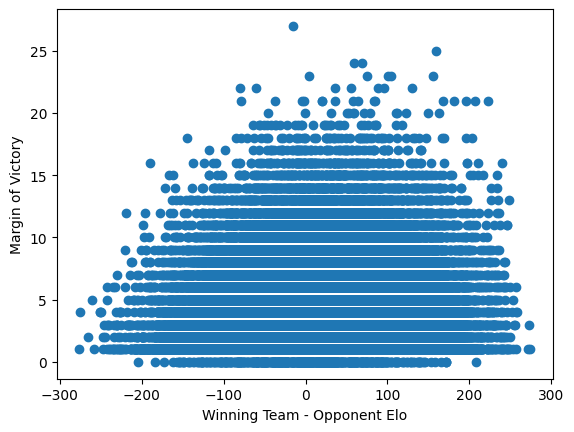

In [53]:
plt.scatter(all_games_elos['winningelodiff'], all_games_elos['marginofvictory']**2)
plt.xlabel('Winning Team - Opponent Elo')
plt.ylabel('Margin of Victory')


### With line fitted

Coefficients: [0.00090909]
Intercept: 1.7003602665829125


Text(0, 0.5, 'Margin of Victory')

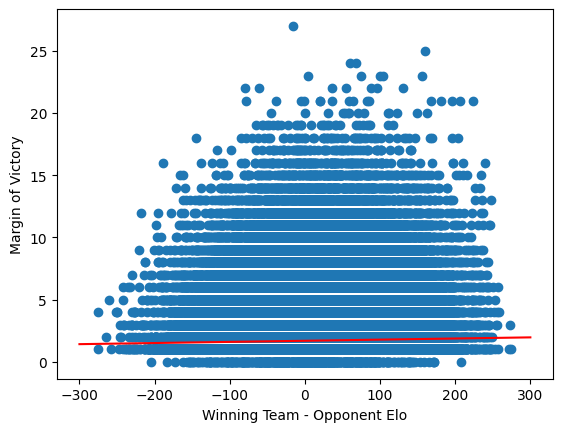

In [119]:
lr = LinearRegression()

lr.fit(all_games_elos['winningelodiff'].to_numpy().reshape(-1,1), all_games_elos['marginofvictory'].to_numpy().reshape(-1,1))

coefs = lr.coef_[0]
intercept = lr.intercept_[0]
print("Coefficients:",coefs)
print("Intercept:",intercept)
xp = np.linspace(-300,300).reshape(-1,1)
yp = lr.predict(xp)

plt.plot(xp,yp,color='red')
plt.scatter(all_games_elos['winningelodiff'], all_games_elos['marginofvictory']**2)
plt.xlabel('Winning Team - Opponent Elo')
plt.ylabel('Margin of Victory')


## Plot Margin counts for a given difference

In [63]:
difference = 0
all_games_elos_difference = all_games_elos[all_games_elos['winningelodiff'] == difference]
all_games_elos_difference.head()

,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,usedh,...,vispitcherrgs,hometeamrgs,visteamrgs,homepitcherminusteamrgs,vispitcherminusteamrgs,homelastkwinpct,vislastkwinpct,homeelo,viselo,winningelodiff
gid,,,,,,,,,,,,,,,,,,,,,
LS3189904140,CHN,LS3,LOU03,18990414,0.0,0:00PM,day,NaN,NaN,False,...,39.0,39.0,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,0.0
PHI189904140,WSN,PHI,PHI09,18990414,0.0,0:00PM,day,NaN,NaN,False,...,39.0,39.0,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,0.0
BLN189904150,NY1,BLN,BAL07,18990415,0.0,0:00PM,day,NaN,NaN,False,...,39.0,39.0,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,0.0
BRO189904150,BSN,BRO,NYC12,18990415,0.0,0:00PM,day,NaN,NaN,False,...,39.0,39.0,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,0.0
CIN189904150,PIT,CIN,CIN05,18990415,0.0,0:00PM,day,NaN,NaN,False,...,39.0,39.0,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,0.0


Text(0, 0.5, 'Games')

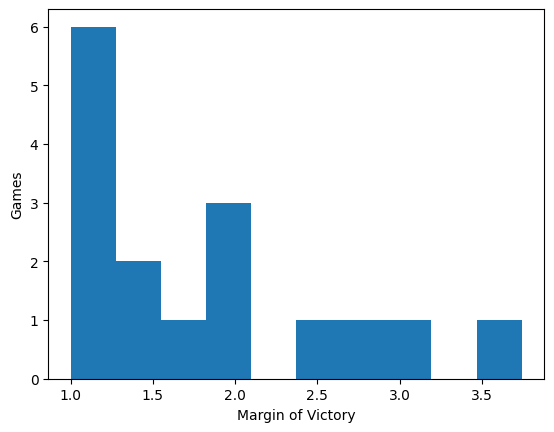

In [67]:
plt.hist(all_games_elos_difference['marginofvictory'])
plt.xlabel('Margin of Victory')
plt.ylabel('Games')

In [65]:
all_games_elos_difference['marginofvictory'].mean()

1.7862532616636484

(array([8.25883333e-01, 5.78600000e-01, 0.00000000e+00, 2.04250000e-01,
        0.00000000e+00, 4.77166667e-02, 8.76666667e-03, 0.00000000e+00,
        1.30000000e-03, 1.50000000e-04]),
 array([1. , 1.6, 2.2, 2.8, 3.4, 4. , 4.6, 5.2, 5.8, 6.4, 7. ]),
 <BarContainer object of 10 artists>)

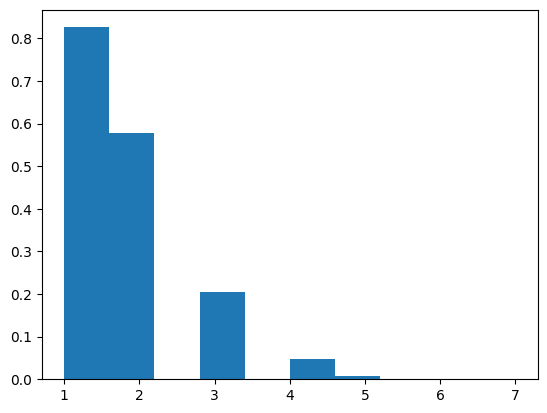

In [66]:
samples = []

for _ in range(100000):
    samples.append(poisson.rvs(mu=0.7, loc=1))
    
plt.hist(samples,density=True)